In [2]:
pip install matminer

  Using cached tqdm-4.66.2-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.4 MB 1.1 MB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.4 MB 1.9 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.4 MB 2.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.5/1.4 MB 2.5 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.4 MB 3.2 MB/s eta 0:00:01
   ------------------------- -------------- 0.9/1.4 MB 3.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.1/1.4 MB 3.2 MB/s eta 0:00:01
   --------------------------------- ------ 1.2/1.4 MB 3.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.4 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.9 MB/s eta 0:00:00
   --------------------------------------

In [1]:
from matminer.datasets import load_dataset

df = load_dataset ('elastic_tensor_2015', data_home = '.')
df.head ()

,material_id,formula,nsites,space_group,volume,structure,elastic_anisotropy,G_Reuss,G_VRH,G_Voigt,K_Reuss,K_VRH,K_Voigt,poisson_ratio,compliance_tensor,elastic_tensor,elastic_tensor_original,cif,kpoint_density,poscar
0,mp-10003,Nb4CoSi,12,124,194.419802,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,96.844535,97.141604,97.438674,194.267623,194.268884,194.270146,0.285701,"[[0.004385293093993, -0.0016070693558990002, -...","[[311.33514638650246, 144.45092552856926, 126....","[[311.33514638650246, 144.45092552856926, 126....",#\#CIF1.1\n###################################...,7000,Nb8 Co2 Si2\n1.0\n6.221780 0.000000 0.000000\n...
1,mp-10010,Al(CoSi)2,5,164,61.987320,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,93.939650,96.252006,98.564362,173.647763,175.449907,177.252050,0.268105,"[[0.0037715428949660003, -0.000844229828709, -...","[[306.93357350984974, 88.02634955100905, 105.6...","[[306.93357350984974, 88.02634955100905, 105.6...",#\#CIF1.1\n###################################...,7000,Al1 Co2 Si2\n1.0\n3.932782 0.000000 0.000000\n...
2,mp-10015,SiOs,2,221,25.952539,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,120.962289,130.112955,139.263621,295.077545,295.077545,295.077545,0.307780,"[[0.0019959391925840004, -0.000433146670736000...","[[569.5291276937579, 157.8517489654999, 157.85...","[[569.5291276937579, 157.8517489654999, 157.85...",#\#CIF1.1\n###################################...,7000,Si1 Os1\n1.0\n2.960692 0.000000 0.000000\n0.00...
3,mp-10021,Ga,4,63,76.721433,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,12.205989,15.101901,17.997812,49.025963,49.130670,49.235377,0.360593,"[[0.021647143908635, -0.005207263618160001, -0...","[[69.28798774976904, 34.7875015216915, 37.3877...","[[70.13259066665267, 40.60474945058445, 37.387...",#\#CIF1.1\n###################################...,7000,Ga4\n1.0\n2.803229 0.000000 0.000000\n0.000000...
4,mp-10025,SiRu2,12,62,160.300999,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,100.110773,101.947798,103.784823,255.055257,256.768081,258.480904,0.324682,"[[0.00410214297725, -0.001272204332729, -0.001...","[[349.3767766177825, 186.67131003104407, 176.4...","[[407.4791016459293, 176.4759188081947, 213.83...",#\#CIF1.1\n###################################...,7000,Si4 Ru8\n1.0\n4.037706 0.000000 0.000000\n0.00...


In [2]:
to_keep = ['formula', 'structure', 'K_VRH']
df = df[to_keep]
df.head()

,formula,structure,K_VRH
0,Nb4CoSi,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",194.268884
1,Al(CoSi)2,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",175.449907
2,SiOs,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",295.077545
3,Ga,"[[0. 1.09045794 0.84078375] Ga, [0. ...",49.130670
4,SiRu2,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",256.768081


In [3]:
from matminer.featurizers.conversions import StrToComposition

df = StrToComposition().featurize_dataframe (df, 'formula')
df.head()

StrToComposition:   0%|          | 0/1181 [00:00<?, ?it/s]

,formula,structure,K_VRH,composition
0,Nb4CoSi,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",194.268884,"(Nb, Co, Si)"
1,Al(CoSi)2,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",175.449907,"(Al, Co, Si)"
2,SiOs,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",295.077545,"(Si, Os)"
3,Ga,"[[0. 1.09045794 0.84078375] Ga, [0. ...",49.130670,(Ga)
4,SiRu2,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",256.768081,"(Si, Ru)"


In [4]:
help (df.head)

Help on method head in module pandas.core.generic:

head(n: 'int' = 5) -> 'FrameOrSeries' method of pandas.core.frame.DataFrame instance
    Return the first `n` rows.
    
    This function returns the first `n` rows for the object based
    on position. It is useful for quickly testing if your object
    has the right type of data in it.
    
    For negative values of `n`, this function returns all rows except
    the last `n` rows, equivalent to ``df[:-n]``.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    same type as caller
        The first `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.tail: Returns the last `n` rows.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >>> df
          animal
    0  alligator
    1        bee
    2     falcon

In [5]:
from matminer.featurizers.composition import ElementProperty
ep_feat = ElementProperty.from_preset (preset_name = 'magpie')
df = ep_feat.featurize_dataframe (df, col_id = 'composition')
df.head ()

ElementProperty:   0%|          | 0/1181 [00:00<?, ?it/s]

,formula,structure,K_VRH,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Nb4CoSi,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",194.268884,"(Nb, Co, Si)",14.0,41.0,27.0,34.166667,9.111111,41.0,...,1.548471,0.258079,0.430131,0.0,194.0,229.0,35.0,222.833333,9.611111,229.0
1,Al(CoSi)2,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",175.449907,"(Al, Co, Si)",13.0,27.0,14.0,19.000000,6.400000,14.0,...,1.548471,0.619388,0.743266,0.0,194.0,227.0,33.0,213.400000,15.520000,194.0
2,SiOs,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",295.077545,"(Si, Os)",14.0,76.0,62.0,45.000000,31.000000,14.0,...,0.000000,0.000000,0.000000,0.0,194.0,227.0,33.0,210.500000,16.500000,194.0
3,Ga,"[[0. 1.09045794 0.84078375] Ga, [0. ...",49.130670,(Ga),31.0,31.0,0.0,31.000000,0.000000,31.0,...,0.000000,0.000000,0.000000,0.0,64.0,64.0,0.0,64.000000,0.000000,64.0
4,SiRu2,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",256.768081,"(Si, Ru)",14.0,44.0,30.0,34.000000,13.333333,44.0,...,0.000000,0.000000,0.000000,0.0,194.0,227.0,33.0,205.000000,14.666667,194.0


In [6]:
from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates

df = CompositionToOxidComposition (). featurize_dataframe (df, 'composition')
df.head ()

CompositionToOxidComposition:   0%|          | 0/1181 [00:00<?, ?it/s]

,formula,structure,K_VRH,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,...,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid
0,Nb4CoSi,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",194.268884,"(Nb, Co, Si)",14.0,41.0,27.0,34.166667,9.111111,41.0,...,0.258079,0.430131,0.0,194.0,229.0,35.0,222.833333,9.611111,229.0,"(Nb0+, Co0+, Si0+)"
1,Al(CoSi)2,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",175.449907,"(Al, Co, Si)",13.0,27.0,14.0,19.000000,6.400000,14.0,...,0.619388,0.743266,0.0,194.0,227.0,33.0,213.400000,15.520000,194.0,"(Al3+, Co2+, Co3+, Si4-)"
2,SiOs,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",295.077545,"(Si, Os)",14.0,76.0,62.0,45.000000,31.000000,14.0,...,0.000000,0.000000,0.0,194.0,227.0,33.0,210.500000,16.500000,194.0,"(Si4-, Os4+)"
3,Ga,"[[0. 1.09045794 0.84078375] Ga, [0. ...",49.130670,(Ga),31.0,31.0,0.0,31.000000,0.000000,31.0,...,0.000000,0.000000,0.0,64.0,64.0,0.0,64.000000,0.000000,64.0,(Ga0+)
4,SiRu2,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",256.768081,"(Si, Ru)",14.0,44.0,30.0,34.000000,13.333333,44.0,...,0.000000,0.000000,0.0,194.0,227.0,33.0,205.000000,14.666667,194.0,"(Si4-, Ru2+)"


In [7]:
os_feat = OxidationStates()
df = os_feat.featurize_dataframe(df, 'composition_oxid')
df.head()

OxidationStates:   0%|          | 0/1181 [00:00<?, ?it/s]

,formula,structure,K_VRH,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,...,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid,minimum oxidation state,maximum oxidation state,range oxidation state,std_dev oxidation state
0,Nb4CoSi,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",194.268884,"(Nb, Co, Si)",14.0,41.0,27.0,34.166667,9.111111,41.0,...,229.0,35.0,222.833333,9.611111,229.0,"(Nb0+, Co0+, Si0+)",0,0,0,0.000000
1,Al(CoSi)2,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",175.449907,"(Al, Co, Si)",13.0,27.0,14.0,19.000000,6.400000,14.0,...,227.0,33.0,213.400000,15.520000,194.0,"(Al3+, Co2+, Co3+, Si4-)",-4,3,7,3.872983
2,SiOs,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",295.077545,"(Si, Os)",14.0,76.0,62.0,45.000000,31.000000,14.0,...,227.0,33.0,210.500000,16.500000,194.0,"(Si4-, Os4+)",-4,4,8,5.656854
3,Ga,"[[0. 1.09045794 0.84078375] Ga, [0. ...",49.130670,(Ga),31.0,31.0,0.0,31.000000,0.000000,31.0,...,64.0,0.0,64.000000,0.000000,64.0,(Ga0+),0,0,0,0.000000
4,SiRu2,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",256.768081,"(Si, Ru)",14.0,44.0,30.0,34.000000,13.333333,44.0,...,227.0,33.0,205.000000,14.666667,194.0,"(Si4-, Ru2+)",-4,2,6,4.242641


In [8]:
from matminer.featurizers.structure import DensityFeatures

In [9]:
df_feat = DensityFeatures()
df = df_feat.featurize_dataframe (df, 'structure')
df.head()

DensityFeatures:   0%|          | 0/1181 [00:00<?, ?it/s]

,formula,structure,K_VRH,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,...,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid,minimum oxidation state,maximum oxidation state,range oxidation state,std_dev oxidation state,density,vpa,packing fraction
0,Nb4CoSi,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",194.268884,"(Nb, Co, Si)",14.0,41.0,27.0,34.166667,9.111111,41.0,...,9.611111,229.0,"(Nb0+, Co0+, Si0+)",0,0,0,0.000000,7.834556,16.201654,0.688834
1,Al(CoSi)2,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",175.449907,"(Al, Co, Si)",13.0,27.0,14.0,19.000000,6.400000,14.0,...,15.520000,194.0,"(Al3+, Co2+, Co3+, Si4-)",-4,3,7,3.872983,5.384968,12.397466,0.644386
2,SiOs,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",295.077545,"(Si, Os)",14.0,76.0,62.0,45.000000,31.000000,14.0,...,16.500000,194.0,"(Si4-, Os4+)",-4,4,8,5.656854,13.968635,12.976265,0.569426
3,Ga,"[[0. 1.09045794 0.84078375] Ga, [0. ...",49.130670,(Ga),31.0,31.0,0.0,31.000000,0.000000,31.0,...,0.000000,64.0,(Ga0+),0,0,0,0.000000,6.036267,19.180359,0.479802
4,SiRu2,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",256.768081,"(Si, Ru)",14.0,44.0,30.0,34.000000,13.333333,44.0,...,14.666667,194.0,"(Si4-, Ru2+)",-4,2,6,4.242641,9.539514,13.358418,0.598395


In [12]:
y = df['K_VRH'].values
excluded = ['K_VRH', 'formula', 'structure', 'composition', 'composition_oxid']
X = df.drop(excluded, axis = 1)
print ('There are %s possible descriptor: \n' % X.shape[1])

There are 139 possible descriptor: 



In [13]:
print ('%s' %X.columns. values)

['MagpieData minimum Number' 'MagpieData maximum Number'
 'MagpieData range Number' 'MagpieData mean Number'
 'MagpieData avg_dev Number' 'MagpieData mode Number'
 'MagpieData minimum MendeleevNumber' 'MagpieData maximum MendeleevNumber'
 'MagpieData range MendeleevNumber' 'MagpieData mean MendeleevNumber'
 'MagpieData avg_dev MendeleevNumber' 'MagpieData mode MendeleevNumber'
 'MagpieData minimum AtomicWeight' 'MagpieData maximum AtomicWeight'
 'MagpieData range AtomicWeight' 'MagpieData mean AtomicWeight'
 'MagpieData avg_dev AtomicWeight' 'MagpieData mode AtomicWeight'
 'MagpieData minimum MeltingT' 'MagpieData maximum MeltingT'
 'MagpieData range MeltingT' 'MagpieData mean MeltingT'
 'MagpieData avg_dev MeltingT' 'MagpieData mode MeltingT'
 'MagpieData minimum Column' 'MagpieData maximum Column'
 'MagpieData range Column' 'MagpieData mean Column'
 'MagpieData avg_dev Column' 'MagpieData mode Column'
 'MagpieData minimum Row' 'MagpieData maximum Row' 'MagpieData range Row'
 'MagpieD

In [ ]:
# decision tree regression
from sklearn import tree
from sklearn.metrics import mean_squared_error
import numpy as np

clf = tree.DecisionTreeRegressor()
clf = clf.fit (X, y)

In [16]:
print ('R2 = ' + str(round(clf.score(X, y), 3)))
print ('RMSE = %.3f' %np.sqrt(mean_squared_error(y_true = y, y_pred = clf.predict (X))))

R2 = 1.0
RMSE = 0.000


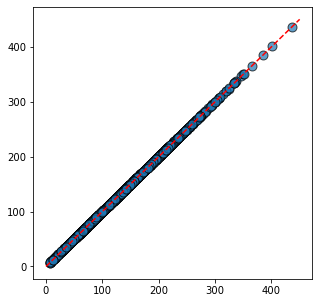

In [18]:
import matplotlib.pyplot as plt

plt.figure (figsize = (5, 5))
plt.plot ([0, 450], [0, 450], 'r--')
plt.scatter (y, clf.predict (X), s = 80, edgecolor = 'k', alpha = 0.7)

In [ ]:
#cross validation
from sklearn.model_selection import KFold, cross_val_score

crossvalidation = KFold(n_splits = 10, shuffle = True)
r2_scores = cross_val_score (clf, X, y, scoring = 'r2', cv = crossvalidation)
rmse_scores = cross_val_score(clf, X, y, scoring = 'neg_root_mean_squared_error', cv = crossvalidation)

print ('Cross-validation results:')
print ('Folds: %i, mean R2: %.3f' %(len(r2_scores), np.mean(r2_scores)))
print ('Folds: %i, mean RMSE: %.3f' % (len(rmse_scores), -np.mean(rmse_scores)))

Cross-validation results:
Folds: 10, mean R2: 0.854
Folds: 10, mean RMSE: 25.066


In [24]:
from sklearn.model_selection import cross_val_predict
y_cv = cross_val_predict (clf, X, y, cv = crossvalidation)

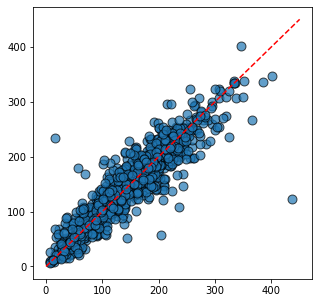

In [28]:
plt.figure (figsize = (5, 5))
plt.plot ([0, 450], [0, 450], 'r--')
plt.scatter (y, y_cv, s = 80, edgecolor = 'k', alpha = 0.7)

In [ ]:
# random forest regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor (n_estimators = 50, random_state = 1)
rf.fit (X, y)

print ('R2 = ' + str(round(rf.score(X, y), 3)))
print ('RMSE = %.3f' %np.sqrt(mean_squared_error(y_true = y, y_pred = rf.predict (X))))

R2 = 0.989
RMSE = 7.669


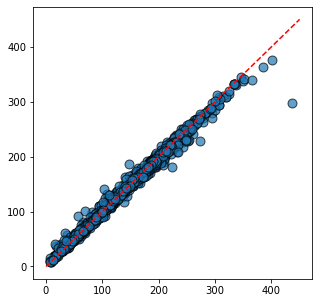

In [31]:
import matplotlib.pyplot as plt

plt.figure (figsize = (5, 5))
plt.plot ([0, 450], [0, 450], 'r--')
plt.scatter (y, rf.predict (X), s = 80, edgecolor = 'k', alpha = 0.7)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 1 )

In [34]:
rf_reg = RandomForestRegressor (n_estimators = 50, random_state = 1)
rf_reg.fit (X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=1)

In [36]:
print ('training R2 = %.3f' % rf_reg.score (X_train, y_train))
print ('training RMSE = %.3f' % rf_reg.score (X_test, y_test))

training R2 = 0.987
training RMSE = 0.941


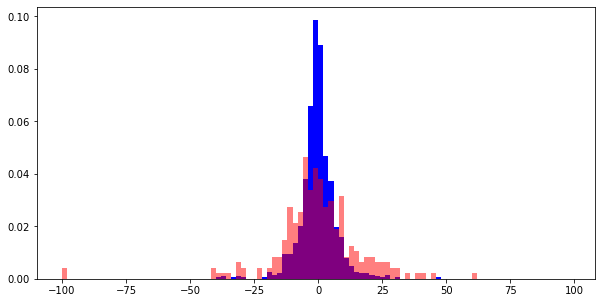

In [45]:
plt.figure (figsize = (10, 5))

plt.hist (y_train-rf_reg.predict (X_train), color = 'blue', bins = np.arange (-100, 100, 2), density = True)
plt.hist (y_test-rf_reg.predict (X_test), color = 'red', bins = np.arange (-100, 100, 2), density = True, alpha = 0.5)
plt.show ()

In [46]:
from sklearn.model_selection import KFold, cross_val_score

crossvalidation = KFold(n_splits = 10, shuffle = True)
r2_scores = cross_val_score (rf, X, y, scoring = 'r2', cv = crossvalidation)
rmse_scores = cross_val_score(rf, X, y, scoring = 'neg_root_mean_squared_error', cv = crossvalidation)

print ('Cross-validation results:')
print ('Folds: %i, mean R2: %.3f' %(len(r2_scores), np.mean(r2_scores)))
print ('Folds: %i, mean RMSE: %.3f' % (len(rmse_scores), -np.mean(rmse_scores)))

Cross-validation results:
Folds: 10, mean R2: 0.927
Folds: 10, mean RMSE: 19.483


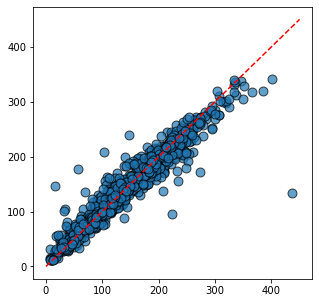

In [48]:
import matplotlib.pyplot as plt

plt.figure (figsize = (5, 5))
plt.plot ([0, 450], [0, 450], 'r--')
plt.scatter (y, cross_val_predict (rf, X, y, cv = crossvalidation), s = 80, edgecolor = 'k', alpha = 0.7)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

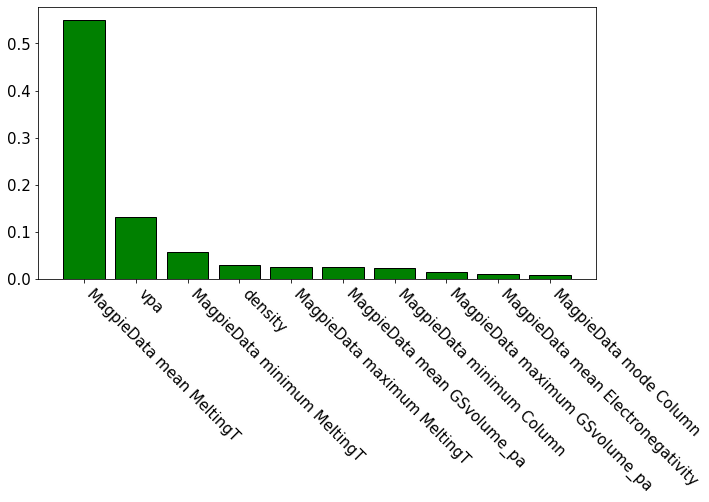

In [58]:
importances = rf.feature_importances_
included = X.columns.values
indices = np.argsort (importances)[::-1]

plt.figure (figsize = (10, 5))
plt.bar (x = included[indices][0:10], height = importances[indices][0:10], color = 'g', edgecolor = 'k')
plt.xticks (rotation = -45, fontsize = 15, ha = 'left')
plt.yticks (fontsize = 15)

In [50]:
print (importances)

[4.40712474e-04 6.54741406e-04 5.99846961e-04 1.17981081e-03
 7.58035936e-04 5.80931843e-04 4.59877531e-03 3.64958305e-04
 5.62443475e-03 4.43010155e-03 1.81388485e-03 2.18054389e-03
 2.03998586e-04 1.15983948e-03 5.06932236e-04 1.03437288e-03
 6.88063107e-04 1.95877313e-04 5.72039891e-02 2.51611134e-02
 1.63038139e-03 5.50037280e-01 4.03696630e-03 1.90744034e-03
 2.21797165e-02 2.01967246e-04 3.87091889e-04 2.01298004e-03
 1.97823806e-03 7.62181788e-03 5.52858051e-05 7.87717947e-05
 1.38452836e-04 1.15350338e-03 9.87603408e-04 3.60646547e-05
 3.17243579e-04 1.84019058e-03 7.14247700e-04 2.83536329e-03
 8.36229659e-04 6.85368975e-04 3.27483425e-03 5.37164964e-04
 1.08572953e-03 1.12162608e-02 1.46618721e-03 3.79214652e-03
 1.53470823e-04 1.82252004e-05 1.19601903e-04 8.59531245e-04
 4.59790761e-04 1.72044994e-04 5.90403390e-05 3.09377010e-05
 2.82190768e-05 1.02783972e-03 6.37105255e-04 2.14024050e-05
 1.81954445e-04 2.75413055e-03 4.02123981e-04 6.25930041e-04
 1.19133986e-03 5.082425

In [ ]:

a = [3, 1, 4, 2, 5, 9]
print (np.argsort(a)[::-1])

[5 4 2 0 3 1]


In [54]:
a = [3, 1, 4, 2, 5, 9]
print (np.argsort(a)[::1])

[1 3 0 2 4 5]


In [59]:
print (indices)

[ 21 137  18 136  19 111  24 109  45  29  77 105   8 138   6   9  94  22
  47 113  42  39 107  61  11  27  28 112 110  23  37  10 106  20  75  46
 104  81 129  93 102  95  64   3  72  13  33 135  44  15  57  34 130 108
  51  92  40   4  73 103 117  38  16  41   1  88  58  63 119   2   5  76
  43  65  14  83 128 123  52  87   0 127 131 118  62  26   7  74  36 132
  82  86 134 124  69  12  25  17 116  90  60 133  70  53  48  85  32 126
  50  91  89  31 121 122  54  84  30 115 125  35  80  55  78  79  56  67
  59  68  49 120  71 114  66 100  99  98  97  96 101]
